<a href="https://colab.research.google.com/github/Mikhailo-Dzham/ADS/blob/main/lab01Dzham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Розподіл та $P(M)$**

Монету підкидають 4 рази. Для кожного підкидання:
$$
\delta_j =
\begin{cases}
1, & \text{якщо випав герб} \\
-1, & \text{якщо випала решка}
\end{cases}
$$

Випадкова величина:
$$
\xi = \sum_{j=1}^{4}\delta_j
$$

Тоді $\xi$ може набувати значень:
$$
\xi \in \{-4,-2,0,2,4\}
$$

Ймовірності:
$$
P(\xi=-4)=\frac{1}{16}, \quad
P(\xi=-2)=\frac{4}{16}, \quad
P(\xi=0)=\frac{6}{16},
$$
$$
P(\xi=2)=\frac{4}{16}, \quad
P(\xi=4)=\frac{1}{16}
$$

Нам потрібно знайти ймовірність події:
$$
M=\{\xi=0\}
$$

Тому:
$$
P(M)=P(\xi=0)=\frac{6}{16}=\frac{3}{8}=0.375
$$

---

**2. Обчислення математичного сподівання та дисперсії**

$$
E[\xi]=\sum x_i P(\xi=x_i)
$$

$$
E[\xi]=
(-4)\cdot\frac{1}{16}
+(-2)\cdot\frac{4}{16}
+0\cdot\frac{6}{16}
+2\cdot\frac{4}{16}
+4\cdot\frac{1}{16}
=0
$$

Для дисперсії знайдемо спочатку $E[\xi^2]$:
$$
E[\xi^2]=
16\cdot\frac{1}{16}
+4\cdot\frac{4}{16}
+0
+4\cdot\frac{4}{16}
+16\cdot\frac{1}{16}
=4
$$

$$
Var[\xi]=E[\xi^2]-(E[\xi])^2
$$

$$
Var[\xi]=4-0^2=4
$$

In [19]:
#===========================================
#Блок для функцій і констант
#===========================================

import random

# Константи
H = 1  # голова, герб та її величина
T = -1  # Хвіст, номінал та ЇЇ величина
J = 4  # Кількість повторів. Загалом я буду намагатися робити код більш гнучким щодо зміни констант
M = 0
N = 1000_000

all_vars = 2**J


def get_ksi(h) -> int:
    '''
    Нам всі значення ксі легко отримати за простою формулою,
     яка залежить виключно від кількості випавших гербів
    :param h:
    :return: int
    '''
    return h * H + T * (J - h)


def bf_variants() -> dict:
    variants = {}  # Словник вв в брутфорсі. ключем буде комбінація H та T
    for j in range(2 ** J):
        binj = bin(j)
        ksi = get_ksi(binj.count('1'))  # Я геній. найпростіший сопсіб
        # Перебрати всі варіанти

        variants[bin(j)[2:].zfill(J)] = ksi

    return variants

def simul_variants(n) -> dict:
    '''
    Загалом краще було б збрерігати {комбінація: кільскість повторів}
    Щоб фактично повністю приблало обмеження по пом'яті для кількості симуляцій,
    але навіть так має вистачити на 10_000_000+ симуляцій
    :param n:
    :return:
    '''
    variants = {}
    for j in range(n):
        binj = bin(random.randint(0, (2**J-1)))
        ksi = get_ksi(binj.count('1'))  # Я геній. найпростіший сопсіб
        # Перебрати всі варіанти

        variants[j] = ksi

    return variants


def distribution_fun(variants) -> dict:
    disfun = {}
    for value in variants.values():
        v = int(value)
        disfun[v] = disfun.get(v, 0) + 1

    return disfun


def display_disfun(disfun):
    for key, val in disfun.items():
        print(f"{key}      {val}/{all_vars}      {val / all_vars}")


def p_from(m, disfun):
    return disfun[m] / all_vars


def e_math(disfun, k = 1) -> float:
    e = 0
    for key, val in disfun.items():
        e += key**k * val / all_vars
    return e

def var(disfun, e) -> float:
    ee = e ** 2
    e_dksi = e_math(disfun, 2)
    return e_dksi - ee


In [21]:
d_bf = distribution_fun(bf_variants())
print("Розподіл ксі")
display_disfun(d_bf)

print("\n")
print(f"P(M = 0) = {p_from(M, d_bf)}")

e_ = e_math(d_bf)
print(f"E = {e_}")

var_ = var(d_bf, e_)
print(f"Var = {var_}")

Розподіл ксі
-4      1/16      0.0625
-2      4/16      0.25
0      6/16      0.375
2      4/16      0.25
4      1/16      0.0625


P(M = 0) = 0.375
E = 0.0
Var = 4.0


In [25]:
N = 1000_000 #Копіюєм N щоб не вертатися до гори
all_vars = N

d_s = distribution_fun(simul_variants(N))
print("Розподіл ксі")
display_disfun(d_s)

print("\n")
print(f"P(M = 0) = {p_from(M, d_s)}")

e_ = e_math(d_s)
print(f"E = {e_}")

var_ = var(d_s, e_)
print(f"Var = {var_}")

Розподіл ксі
2      250259/1000000      0.250259
0      375025/1000000      0.375025
-4      62218/1000000      0.062218
-2      249995/1000000      0.249995
4      62503/1000000      0.062503


P(M = 0) = 0.375025
E = 0.0016680000000000583
Var = 3.996549217776


# Задача 2

### Задача №2 теоритична частина

**1. Знаходження сталої $C$**

Маємо щільність:
$$
f(t) = C|\sin(2t)|1_{[0,\pi)}(t)
$$

За властивістю щільності:
$$
\int_{-\infty}^{+\infty} f(t)dt = 1
$$

Оскільки функція ненульова лише на $[0,\pi)$:
$$
\int_{0}^{\pi} C|\sin(2t)|dt = 1
$$

Розіб’ємо інтеграл на ділянки, де $\sin(2t)$ змінює знак:
$$
C\left(\int_{0}^{\pi/2}\sin(2t)dt - \int_{\pi/2}^{\pi}\sin(2t)dt\right)=1
$$

Обчислимо:
$$
\int \sin(2t)dt = -\frac{\cos(2t)}{2}
$$

Тоді:
$$
C\left(
-\frac{\cos(2t)}{2}\Big|_{0}^{\pi/2}
+
\frac{\cos(2t)}{2}\Big|_{\pi/2}^{\pi}
\right)=1
$$

$$
C\left(
-\frac{\cos(\pi)-\cos(0)}{2}
+
\frac{\cos(2\pi)-\cos(\pi)}{2}
\right)=1
$$

$$
C\left(
-\frac{-1-1}{2}
+
\frac{1-(-1)}{2}
\right)=1
$$

$$
C(1+1)=1
$$

$$
2C=1
\implies
C=\frac12
$$

Отже,
$$
f(t)=\frac12|\sin(2t)|, \quad t\in[0,\pi)
$$

---

**2. Функція розподілу $F(t)$**

За означенням:
$$
F(t)=\int_{-\infty}^{t}f(x)dx
$$

### Для $t<0$

$$
F(t)=0
$$

---

### Для $0\le t<\frac{\pi}{2}$

На цьому проміжку:
$$
|\sin(2t)|=\sin(2t)
$$

Тоді:
$$
F(t)=\int_{0}^{t}\frac12\sin(2x)dx
$$

$$
F(t)=\frac12\left(-\frac{\cos(2x)}{2}\right)\Big|_{0}^{t}
$$

$$
F(t)=\frac14(1-\cos(2t))
$$

---

### Для $\frac{\pi}{2}\le t<\pi$

На цьому проміжку:
$$
|\sin(2t)|=-\sin(2t)
$$

Тоді:
$$
F(t)=F\left(\frac{\pi}{2}\right)+\int_{\pi/2}^{t}\frac12(-\sin(2x))dx
$$

Оскільки:
$$
F\left(\frac{\pi}{2}\right)=\frac12
$$

Маємо:
$$
F(t)=\frac12+\frac12\int_{\pi/2}^{t}(-\sin(2x))dx
$$

$$
F(t)=\frac12+\frac12\left(\frac{\cos(2x)}{2}\right)\Big|_{\pi/2}^{t}
$$

$$
F(t)=\frac12+\frac14(\cos(2t)+1)
$$

$$
F(t)=\frac34+\frac14\cos(2t)
$$

---

### Для $t\ge\pi$

$$
F(t)=1
$$

---

Отже:
$$
F(t)=
\begin{cases}
0, & t<0 \\
\frac14(1-\cos(2t)), & 0\le t<\frac{\pi}{2} \\
\frac34+\frac14\cos(2t), & \frac{\pi}{2}\le t<\pi \\
1, & t\ge\pi
\end{cases}
$$

---

**3. Обчислення математичного сподівання та дисперсії**

Математичне сподівання:
$$
E[\xi]=\int_{0}^{\pi} t\cdot \frac12 |\sin(2t)|dt
$$

Функція щільності симетрична відносно точки:
$$
t=\frac{\pi}{2}
$$

Тому:
$$
E[\xi]=\frac{\pi}{2}
$$

---

Знайдемо:
$$
E[\xi^2]
=
\int_{0}^{\pi} t^2\cdot \frac12 |\sin(2t)|dt
$$

Розіб’ємо інтеграл:
$$
E[\xi^2]
=
\frac12\int_{0}^{\pi/2} t^2\sin(2t)dt
-
\frac12\int_{\pi/2}^{\pi} t^2\sin(2t)dt
$$

Після інтегрування частинами отримуємо:
$$
E[\xi^2]=\frac{\pi^2}{4}-\frac12
$$

Тоді дисперсія:
$$
Var[\xi]
=
E[\xi^2]-(E[\xi])^2
$$

$$
Var[\xi]
=
\left(\frac{\pi^2}{4}-\frac12\right)
-
\left(\frac{\pi}{2}\right)^2
$$

$$
Var[\xi]=\frac12
$$

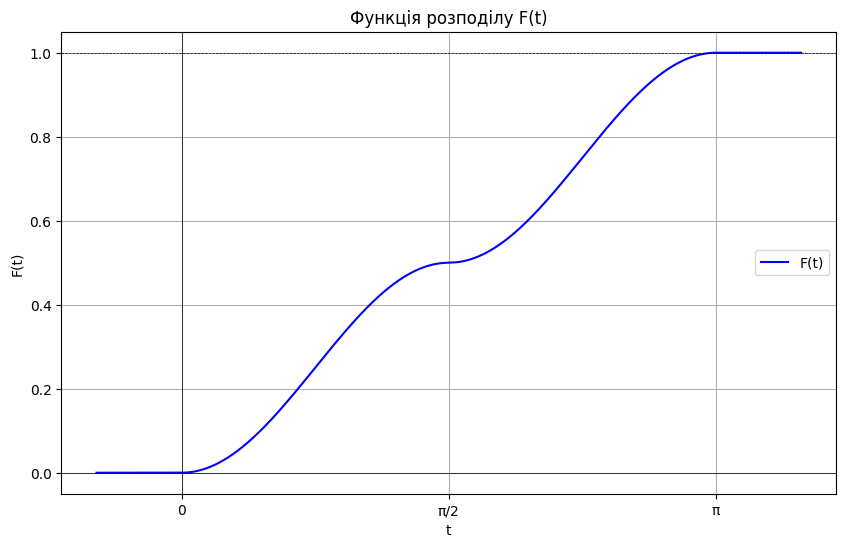

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Щільність розподілу (для повноти картини)
def f(t):
    return 0.5 * np.abs(np.sin(2 * t)) * ((t >= 0) & (t < np.pi))

# Теоретична функція розподілу F(t) згідно з вашими розрахунками
def F(t):
    return np.where(t < 0, 0,
           np.where(t < np.pi / 2, 0.25 * (1 - np.cos(2 * t)),
           np.where(t < np.pi, 0.75 + 0.25 * np.cos(2 * t), 1)))

# Задаємо діапазон значень t для побудови графіка (трохи ширше за [0, pi])
t_values = np.linspace(-0.5, np.pi + 0.5, 500)
F_values = F(t_values)

# Побудова графіка
plt.figure(figsize=(10, 6))
plt.plot(t_values, F_values, label='F(t)', color='blue')
plt.title('Функція розподілу F(t)')
plt.xlabel('t')
plt.ylabel('F(t)')
plt.grid(True)
plt.legend()

# Додаткові лінії осей та асимптоти
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.axhline(1, color='black', linewidth=0.5, linestyle='--')

# Налаштування позначок на осі X
plt.xticks([0, np.pi/2, np.pi], ['0', 'π/2', 'π'])

# Відображення графіка
plt.show()